In [2]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
os.chdir('C:/Users/Tom/Desktop/east_africa_conflict_analysis/')

Current working directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Files in current directory: ['exploratory_data_analysis.ipynb']


In [3]:
from src.data_cleaning import clean_data_pipeline

data = clean_data_pipeline()



Starting data cleaning pipeline...
<class 'xarray.core.dataarray.DataArray'>
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\kenya_police.parquet


c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'gadm41_KEN_shp': 'gadm41_KEN_0' (default), 'gadm41_KEN_1', 'gadm41_KEN_2', 'gadm41_KEN_3'. Specify layer parameter to avoid this warning.
  result = read_func(


Reprojection required: ken - police (Current: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope": "Horizontal c

c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'gadm41_KEN_shp': 'gadm41_KEN_0' (default), 'gadm41_KEN_1', 'gadm41_KEN_2', 'gadm41_KEN_3'. Specify layer parameter to avoid this warning.
  result = read_func(


Replaced 100024073 missing values (-99999.0) with 0 in ken - population
Min: 0.0
Data cleaning complete.


In [3]:
data

{'eth': {},
 'ken': {'acled':                     WEEK          REGION COUNTRY      ADMIN1  \
  82503    24-January-1998  Eastern Africa   Kenya     Baringo   
  82504    16-January-1999  Eastern Africa   Kenya     Baringo   
  82505  25-September-1999  Eastern Africa   Kenya     Baringo   
  82506     07-August-2004  Eastern Africa   Kenya     Baringo   
  82507      02-April-2005  Eastern Africa   Kenya     Baringo   
  ...                  ...             ...     ...         ...   
  96899   07-December-2024  Eastern Africa   Kenya  West Pokot   
  96900     23-August-2025  Eastern Africa   Kenya  West Pokot   
  96901      09-April-2022  Eastern Africa   Kenya  West Pokot   
  96902        13-May-2023  Eastern Africa   Kenya  West Pokot   
  96903      16-March-2024  Eastern Africa   Kenya  West Pokot   
  
                         EVENT_TYPE   SUB_EVENT_TYPE  EVENTS  FATALITIES  \
  82503                     Battles      Armed clash       1           0   
  82504                  

In [12]:
import pandas as pd
import geopandas as gpd

COMMON_CRS = "EPSG:32637"

    # ACLED conflict data
acled_df = pd.read_csv("../data/Africa_aggregated_data_up_to-2025-08-23.csv")
acled_gdf = gpd.GeoDataFrame(
        acled_df,
        geometry=gpd.points_from_xy(
            acled_df['CENTROID_LONGITUDE'], 
            acled_df['CENTROID_LATITUDE']
        ),
        crs=COMMON_CRS
        )
    

acled_gdf[acled_gdf['COUNTRY'] == 'Kenya'].head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,geometry
82503,24-January-1998,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82504,16-January-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82505,25-September-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82506,07-August-2004,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)
82507,02-April-2005,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.018 0.72)


In [3]:
acled = gpd.read_file(
            "../data/Africa_aggregated_data_up_to-2025-08-23.csv",
            x='CENTROID_LONGITUDE',
            y='CENTROID_LATITUDE',
            crs='EPSG:4326'
        )

c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver CSV does not support open option X
  return ogr_read(
c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver CSV does not support open option Y
  return ogr_read(
c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver CSV does not support open option CRS
  return ogr_read(


In [8]:
acled.head()
type(acled)

pandas.core.frame.DataFrame

In [13]:
import os
print("Current directory:", os.getcwd())
print("Parent directory contents:", os.listdir('..'))
if os.path.exists('../data/'):
    print("Data directory contents:", os.listdir('../data/'))

Current directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Parent directory contents: ['.git', '.gitignore', 'data', 'docs', 'main.py', 'notebooks', 'README.md', 'requirements.txt', 'src']
Data directory contents: ['Africa_aggregated_data_up_to-2025-08-23.csv', 'eth_pop_2020_CN_100m_R2025A_v1.tif', 'gadm41_ETH_shp', 'gadm41_KEN_shp', 'gadm41_SSD_shp', 'gadm41_UGA_shp', 'ken_pop_2020_CN_100m_R2025A_v1.tif', 'ssd_pop_2020_CN_100m_R2025A_v1.tif', 'uga_pop_2020_CN_100m_R2025A_v1.tif', '_archive']


In [14]:
acled_df = pd.read_csv("../data/Africa_aggregated_data_up_to-2025-08-23.csv")

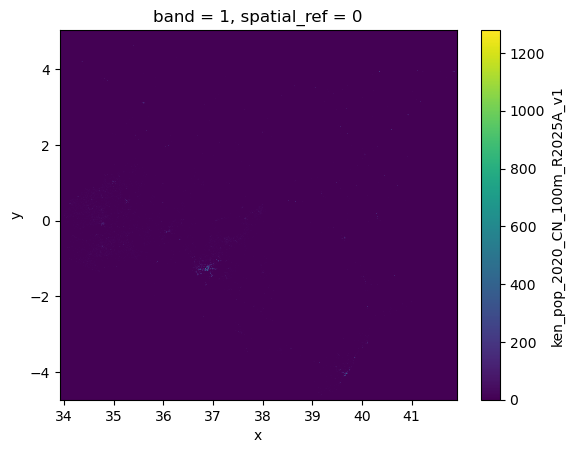

In [4]:
data['ken']['population'].plot()

In [5]:
dataset = data['ken']['population']
print(f"Min: {dataset.min().values}")
dataset_cleaned = dataset.where(dataset != -99999.0, 0)
print(f"Min: {dataset_cleaned.min().values}")

Min: -99999.0
Min: 0.0


In [27]:
import rioxarray as rxr
data['ken']['population'] = rxr.open_rasterio("data/ken_pop_2020_CN_100m_R2025A_v1.tif")
print(type(data['ken']['population'])) 

<class 'xarray.core.dataarray.DataArray'>


In [4]:
data['ken']['population'].rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [6]:
data['ken']['acled'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
data['ken']['police'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
data['ken']['bounds'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [17]:
data['ken']['acled'].head()


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,geometry
82503,24-January-1998,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.0185 0.7197)
82504,16-January-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.0185 0.7197)
82505,25-September-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.0185 0.7197)
82506,07-August-2004,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.0185 0.7197)
82507,02-April-2005,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535.0,0.7197,36.0185,POINT (36.0185 0.7197)


In [4]:
# ACLED: Check for impossible coordinates, extreme casualty numbers
ken_acled = data['ken']['acled']

# Check impossible coordinates (latitude should be between -90 and 90, longitude between -180 and 180)
print("Invalid coordinates:")
print(ken_acled[(ken_acled.geometry.y < -90) | (ken_acled.geometry.y > 90) | 
               (ken_acled.geometry.x < -180) | (ken_acled.geometry.x > 180)])

# Check extreme casualty numbers
print("\nCasualty statistics:")
print(ken_acled['FATALITIES'].describe())
print("\nHigh fatality events (>100):")
print(ken_acled[ken_acled['FATALITIES'] > 100][['WEEK', 'FATALITIES', 'EVENT_TYPE']])

# Boundaries: Check for invalid geometries
ken_bounds = data['ken']['bounds']

print("\nInvalid geometries:")
print(f"Number of invalid geometries: {(~ken_bounds.geometry.is_valid).sum()}")
print(ken_bounds[~ken_bounds.geometry.is_valid])

# Population: Clip extreme values
ken_pop = data['ken']['population']

print("\nPopulation statistics:")
print(f"Min: {ken_pop.min().values}")
print(f"Max: {ken_pop.max().values}")
print(f"Mean: {ken_pop.mean().values}")
print(f"Median: {ken_pop.median().values}")

# Check for extreme values (e.g., above 99th percentile)
percentile_99 = ken_pop.quantile(0.99).values
print(f"\n99th percentile: {percentile_99}")
print(f"Values above 99th percentile: {(ken_pop > percentile_99).sum().values}")

Invalid coordinates:
Empty GeoDataFrame
Columns: [WEEK, REGION, COUNTRY, ADMIN1, EVENT_TYPE, SUB_EVENT_TYPE, EVENTS, FATALITIES, POPULATION_EXPOSURE, DISORDER_TYPE, ID, CENTROID_LATITUDE, CENTROID_LONGITUDE, geometry]
Index: []

Casualty statistics:
count    14401.000000
mean         1.034442
std          5.135206
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        281.000000
Name: FATALITIES, dtype: float64

High fatality events (>100):
                  WEEK  FATALITIES                  EVENT_TYPE
84342    28-March-2015         149  Violence against civilians
88909   14-August-1999         153                     Battles
91233   01-August-1998         213  Explosions/Remote violence
96619  24-October-1998         281  Violence against civilians

Invalid geometries:
Number of invalid geometries: 0
Empty GeoDataFrame
Columns: [GID_0, COUNTRY, geometry]
Index: []

Population statistics:
Min: -99999.0
Max: 1279.02294921875
Mean: -88890.88281